<p align="center">
  <a href="https://imc.uc.cl" target="_blank">
    <img src="attachment:image.png" alt="IMC" width="220">
  </a>
</p>

# IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Profesor:** Rodrigo A. Carrasco <br>
---


## Tarea 04 – Aprendizaje automático

- **Fecha de Entrega:** 13 de noviembre de 2025, a las 23:59.
- **Fecha de publicación**: 30 de octubre de 2025.
- **Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 04 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

### 1.2 Pregunta de ciencia de datos

Esta tarea tendrá como objetivo crear un predictor que determine el éxito o fracaso de una expedición a distintas montañas del Himalayas según datos del montañista y de la expedición. Vamos a responder a la pregunta de qué tan bien pueden atributos como año, estación, montaña, edad del montañista, entre otros, predecir el éxito o fracaso de una expedición.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

[The Himalayan Database](https://www.himalayandatabase.com/) consiste en una colección de registros de expediciones en la cordillera del Himalaya. Esta contiene información detallada de las cimas más altas del mundo, junto con miles de expediciones realizadas desde 1905 hasta 2024 e información de cada uno de los/las montañistas que han participado en ellas. (El dataset que utilizaremos fue extraído desde: https://mavenanalytics.io/data-playground/himalayan-expeditions)

Descargue el archivo `Himalayan+Expeditions.zip` disponible en el repositorio del curso. Como puede ver, esta información está separada en varios archivos `.csv`. Deberá utilizar las herramientas aprendidas durante el curso para juntar esta información, procesarla y crear un predictor que determine el éxito de una subida.

**Recomendación**: Puede revisar el archivo `himalayan_data_dictionary.csv` para saber el significado de cada una de las columnas de la base de datos.

### 2.1 Librerías

Para esta tarea puede utilizar cualquiera de las librerías previamente utilizadas en el curso. Puede agregar otras si lo estima conveniente para el desarrollo de la Tarea.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import sklearn

## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


### 3.1.1 Carga de DataSets:

In [3]:
#1. Definimos las rutas temporales a los DataSets.
ruta_montañas = os.path.join("Himalayan+Expeditions", "peaks_with_exp.csv")
ruta_expediciones = os.path.join("Himalayan+Expeditions", "exped.csv")
ruta_montañistas = os.path.join("Himalayan+Expeditions", "members.csv")

#2. Cargamos los DataSets.
montañas = pd.read_csv(ruta_montañas)
expediciones = pd.read_csv(ruta_expediciones, low_memory = False)
montañistas = pd.read_csv(ruta_montañistas, low_memory = False)

In [4]:
#3. Definimos las columnas de interés.
df_montañas = montañas[["peakid", "pkname", "heightm", "success_exp", "failed_exp"]]

#En el caso de las expediciones y montañistas, incluimos las columnas "peakid" y "expid" para facilitar futuras uniones entre DataFrames.
df_expediciones = expediciones[["expid", "peakid", "year", "season"]]

#Además, en el DataFrame de montañistas incluimos las columnas "fname" y "lname" para tener los nombres completos de los montañistas y facilitar su identificación.
df_montañistas = montañistas[["membid", "fname", "lname", "expid", "peakid", "sex", "yob", "citizen", "msuccess"]]

### 3.1.2 Verificación de DataFrames:

In [5]:
df_montañas.head()

,peakid,pkname,heightm,success_exp,failed_exp
0,ACHN,Aichyn,6055,2,1
1,AMAD,Ama Dablam,6814,1123,453
2,AMOT,Amotsang,6393,1,2
3,AMPG,Amphu Gyabjen,5630,3,1
4,AMPH,Amphu I,6740,1,1


In [6]:
df_expediciones.head()

,expid,peakid,year,season
0,ANN260101,ANN2,1960,Spring
1,ANN269301,ANN2,1969,Autumn
2,ANN273101,ANN2,1973,Spring
3,ANN278301,ANN2,1978,Autumn
4,ANN279301,ANN2,1979,Autumn


In [7]:
df_montañistas.head()

,membid,fname,lname,expid,peakid,sex,yob,citizen,msuccess
0,2,Rohan,Buckley,AMAD01101,AMAD,M,1972.0,Australia,False
1,1,Marc Cameron,Fairhead,AMAD01101,AMAD,M,1968.0,Australia,False
2,3,Mark,Schroeder,AMAD01101,AMAD,M,1960.0,Australia,False
3,4,Colin,Smith,AMAD01101,AMAD,M,1966.0,Australia,False
4,5,Naomi,Smith,AMAD01101,AMAD,F,1970.0,Australia,False


### 3.1.3 Unión de DataFrames:

In [8]:
#1. Unimos los DataFrames en uno solo, tomando como referencia las columnas expid y peakid.

#Para ello, primero unimos el DataFrame de montañistas con el de expediciones, y luego el resultado lo unimos con el de montañas.
df = df_montañistas.merge(df_expediciones, on = ["expid", "peakid"]).merge(df_montañas, on = "peakid")

df.sample(10)

,membid,fname,lname,expid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp
67804,11,Andreas,Paul,EVER91113,EVER,M,NaN,Austria,False,1991,Spring,Everest,8849,1495,852
1527,3,Angel,Terren,AMAD02104,AMAD,M,1973.0,Spain,False,2002,Spring,Ama Dablam,6814,1123,453
13099,4,Marco,Peruffo,AMAD07330,AMAD,M,1969.0,Italy,True,2007,Autumn,Ama Dablam,6814,1123,453
49563,19,Bimal,Purja,LHOT22102,LHOT,M,1995.0,Nepal,True,2022,Spring,Lhotse,8516,318,194
67565,3,Mario Luciano,Panzeri,EVER90304,EVER,M,1964.0,Italy,False,1990,Autumn,Everest,8849,1495,852
12943,9,Jeong-Il,Son,AMAD07311,AMAD,M,1968.0,S Korea,False,2007,Autumn,Ama Dablam,6814,1123,453
40190,6,Lhakpa Tashi,Sherpa,EVER18153,EVER,M,1985.0,Nepal,True,2018,Spring,Everest,8849,1495,852
79115,1,John Hubert,Emlyn Jones,AMPG59101,AMPG,M,1915.0,UK,True,1959,Spring,Amphu Gyabjen,5630,3,1
47479,3,Eduard Udo Alexander,Wagner,AMAD21318,AMAD,M,1977.0,Austria,False,2021,Autumn,Ama Dablam,6814,1123,453
45658,16,Anders Verner,Warell,MANA19334,MANA,M,1970.0,Sweden,True,2019,Autumn,Manaslu,8163,457,318


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

#### 3.2.1 Copia del DataFrame original:

In [9]:
#1. Creamos una copia del DataFrame original
clean_df = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89089 entries, 0 to 89088
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   membid       89089 non-null  int64  
 1   fname        88985 non-null  object 
 2   lname        87964 non-null  object 
 3   expid        89089 non-null  object 
 4   peakid       89089 non-null  object 
 5   sex          89089 non-null  object 
 6   yob          83665 non-null  float64
 7   citizen      89082 non-null  object 
 8   msuccess     89089 non-null  bool   
 9   year         89089 non-null  int64  
 10  season       89089 non-null  object 
 11  pkname       89089 non-null  object 
 12  heightm      89089 non-null  int64  
 13  success_exp  89089 non-null  int64  
 14  failed_exp   89089 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(8)
memory usage: 9.6+ MB


#### 3.2.2 Eliminación de valores duplicados:

In [10]:
#1. Eliminamos valores duplicados
clean_df = clean_df.drop_duplicates()

clean_df.shape

(89089, 15)

No se han encontrado valores duplicados.

#### 3.2.3 Eliminación de valores nulos:

Como vimos recientemente, la únicas columnas que contienen valores nulos son "fname", "lname", "yob" y "citizen". El procedimiento de limpieza e imputación para cada columna se detalla a continuación:

* "fname": No es relevante para el análisis, por lo que se imputará el str "Nombre".

* "lname": No es relevante pare el análisis, por lo que se imputará el str "Apellido".

* "citizen": Dado a que hay solo 7 filas cuyo valor en esta columna es nulo, y considerando el volumen total de datos, se opta por eliminar estas entradas.

* "yob": Debido a que es un atributo importante a la hora de definir la matriz de atributos, y considerando que se trata de más de 5.000 datos, optaremos por imputar en los valores nulos el promedio de los años de nacimiento de los demás montañistas de la expedición. En caso de que no tenga compañeros de expedición, se eliminará. 

In [11]:
#1. Eliminamos las filas con valores nulos en "citizen".
clean_df = clean_df.dropna(subset = ["citizen"])
clean_df.shape

(89082, 15)

In [12]:
#2. Imputamos los valores nulos en "fname" y "lname" con "Nombre" y "Apellido" respectivamente.
clean_df["fname"] = clean_df["fname"].fillna("Nombre")
clean_df["lname"] = clean_df["lname"].fillna("Apellido")

Para imputar los valores nulos en "yob", solicité a Gemini que generara una función a partir del siguiente promp:

"Estoy trabajando con un conjunto de datos, particularmente de expediciones llevadas a cabo por varios montañistas a lo largo de los últimos 100 años. Resulta que tengo una columna "yob" que indica el año de nacimiento de cada montañista con varios valores nulos. Quiero que desarrolles una función capaz de imputar los valores nulos en "yob" con el promedio de los años de nacimiento de los demás montañistas dentro de la misma expedición (cuyos valores en la columnas "expid" sean iguales). En caso de que no existan coincidencias en "expid" (porque probablemente el montañista ascendió solo o no se tienen registros de sus compañeros) deja el valor como nulo."

In [13]:
#Código generado por Gemini 2.5 Pro para imputar los valores nulos en "yob":

def imputar_yob(row):
    if pd.isnull(row["yob"]):
        expid = row["expid"]
        promedio_yob = clean_df[clean_df["expid"] == expid]["yob"].mean()
        return round(promedio_yob) if not np.isnan(promedio_yob) else np.nan
    else:
        return row["yob"]

In [14]:
#3. Imputamos los valores nulos en "yob" con el promedio de edad de los demás montañistas de la expedición.
clean_df["yob"] = clean_df.apply(imputar_yob, axis = 1)

In [15]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89082 entries, 0 to 89088
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   membid       89082 non-null  int64  
 1   fname        89082 non-null  object 
 2   lname        89082 non-null  object 
 3   expid        89082 non-null  object 
 4   peakid       89082 non-null  object 
 5   sex          89082 non-null  object 
 6   yob          88652 non-null  float64
 7   citizen      89082 non-null  object 
 8   msuccess     89082 non-null  bool   
 9   year         89082 non-null  int64  
 10  season       89082 non-null  object 
 11  pkname       89082 non-null  object 
 12  heightm      89082 non-null  int64  
 13  success_exp  89082 non-null  int64  
 14  failed_exp   89082 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(8)
memory usage: 10.3+ MB


Como podemos ver, pasamos de tener 5.424 valores nulos a tan solo 437.
Estos últimos deben ser casos particulares en los que no se tiene registro del año de nacimiento de ninguno de los montañistas que formó parte de la expedición.
Debido a que conocer la edad resulta fundamental para el análisis posterior, procederemos a eliminar estas últimas entradas.

In [16]:
#4. Eliminamos las filas que aún contienen valores nulos en "yob".
clean_df = clean_df.dropna(subset = ["yob"])
clean_df.reset_index(drop = True, inplace = True)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88652 entries, 0 to 88651
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   membid       88652 non-null  int64  
 1   fname        88652 non-null  object 
 2   lname        88652 non-null  object 
 3   expid        88652 non-null  object 
 4   peakid       88652 non-null  object 
 5   sex          88652 non-null  object 
 6   yob          88652 non-null  float64
 7   citizen      88652 non-null  object 
 8   msuccess     88652 non-null  bool   
 9   year         88652 non-null  int64  
 10  season       88652 non-null  object 
 11  pkname       88652 non-null  object 
 12  heightm      88652 non-null  int64  
 13  success_exp  88652 non-null  int64  
 14  failed_exp   88652 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(8)
memory usage: 9.6+ MB


#### 3.2.4 Eliminación de valores inválidos:
Corroboraremos que no existan valores inválidos detro del DataFrame, como negativos en columnas numéricas o años fuera de rango.

Para ello, aplicaremos los siguientes criterios:
* "year": Valores desde 1905 hasta 2024 (tal como indica la descripción del DataSet).
* "heightm", "success_exp", "failed_exp", "year", "yob", "msuccess": Deben ser valores positivos.
* "year" - "yob": Debe ser menor a 100 (se asume que no hay montañistas con más de 100 años de edad).

Antes, veamos si existen montañistas con más de 100 años de edad:

In [30]:
#DataFrame de montañistas con más de 100 años de edad en el momento de la expedición.

df_mayores_100 = clean_df[(clean_df["year"] - clean_df["yob"]) > 100]
df_mayores_100.sample(10)

,membid,fname,lname,expid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp
82744,10,Edward Oswald,Shebbeare,EVER24101,EVER,M,1884.0,UK,False,2024,Spring,Everest,8849,1495,852
78734,1,Edward Felix,Norton,EVER24101,EVER,M,1884.0,UK,False,2024,Spring,Everest,8849,1495,852
78732,1,Charles Granville,Bruce,EVER22101,EVER,M,1866.0,UK,False,2022,Spring,Everest,8849,1495,852
82734,2,Bentley,Beetham,EVER24101,EVER,M,1886.0,UK,False,2024,Spring,Everest,8849,1495,852
82700,8,Edward Oliver,Wheeler,EVER21101,EVER,M,1890.0,Canada,False,2021,Spring,Everest,8849,1495,852
82708,2,John Geoffrey,Bruce,EVER22101,EVER,M,1896.0,UK,False,2022,Spring,Everest,8849,1495,852
82736,4,John de Vars,Hazard,EVER24101,EVER,M,1888.0,UK,False,2024,Spring,Everest,8849,1495,852
80276,7,George Herbert Leigh,Mallory,EVER24101,EVER,M,1886.0,UK,False,2024,Spring,Everest,8849,1495,852
82722,10,Edward Felix,Norton,EVER22101,EVER,M,1884.0,UK,False,2022,Spring,Everest,8849,1495,852
82720,7,Charles John,Morris,EVER22101,EVER,M,1895.0,UK,False,2022,Spring,Everest,8849,1495,852


Parece que algo no tiene sentido: ¿Cómo es que Edward Oswald Shebbeare fue capaz de escalar el Everest a sus 140 años?
Edward Oswald Shebbeare fue un alpinista, naturalista y forestal británico, miembro de la expedición británica al Monte Everest en 1924, el cual falleció en el año 1964.
No es el único caso, por lo que claramente es un error del DataSet.

Apliquemos los criterios para descartar valores inválidos del DataFrame:

In [17]:
#1. Eliminamos valores negativos en columnas numéricas.
columnas_numericas = ["heightm", "success_exp", "failed_exp", "year", "yob", "msuccess"]

for col in columnas_numericas:
    clean_df = clean_df[clean_df[col] >= 0] 

clean_df.shape

(88652, 15)

In [18]:
#2. Eliminamos valores fuera de rango en "year".
clean_df = clean_df[clean_df["year"].between(1905, 2024)]
clean_df.shape

(88652, 15)

In [19]:
#3. Eliminamos montañistas con edad mayor a 100 años en el momento de la expedición.
clean_df = clean_df[(clean_df["year"] - clean_df["yob"]) <= 100]
clean_df.shape

(88618, 15)

In [20]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88618 entries, 0 to 88651
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   membid       88618 non-null  int64  
 1   fname        88618 non-null  object 
 2   lname        88618 non-null  object 
 3   expid        88618 non-null  object 
 4   peakid       88618 non-null  object 
 5   sex          88618 non-null  object 
 6   yob          88618 non-null  float64
 7   citizen      88618 non-null  object 
 8   msuccess     88618 non-null  bool   
 9   year         88618 non-null  int64  
 10  season       88618 non-null  object 
 11  pkname       88618 non-null  object 
 12  heightm      88618 non-null  int64  
 13  success_exp  88618 non-null  int64  
 14  failed_exp   88618 non-null  int64  
dtypes: bool(1), float64(1), int64(5), object(8)
memory usage: 10.2+ MB


In [21]:
clean_df.sample(10)

,membid,fname,lname,expid,peakid,sex,yob,citizen,msuccess,year,season,pkname,heightm,success_exp,failed_exp
64353,5,Sante,Guizzo,DHA192305,DHA1,M,1943.0,Italy,False,1992,Autumn,Dhaulagiri I,8167,183,241
49761,5,Luis Nicolas,Miranda Rodriquez,MAKA22102,MAKA,M,1977.0,Ecuador,True,2022,Spring,Makalu,8485,171,212
58353,13,Sonam Wolang,Sherpa,ANN177301,ANN1,M,1943.0,Nepal,True,1977,Autumn,Annapurna I,8091,101,163
88236,11,Garong,Sherpa,EVER21101,EVER,M,1941.0,Nepal,False,2021,Spring,Everest,8849,1495,852
58962,1,Alexander,Glushkovski,ANN191309,ANN1,M,1953.0,USSR,False,1991,Autumn,Annapurna I,8091,101,163
63282,4,William H. (Bill),O'Connor,CHOL82101,CHOL,M,1947.0,UK,True,1982,Spring,Cholatse,6423,19,8
20947,2,Noriyuki,Muraguchi,EVER11124,EVER,M,1956.0,Japan,True,2011,Spring,Everest,8849,1495,852
54821,10,Simon Gregory,Prosser,MANA23313,MANA,M,1967.0,USA,True,2023,Autumn,Manaslu,8163,457,318
21393,5,Robert William (Rob),Hart,EVER11149,EVER,M,1972.0,S Africa,True,2011,Spring,Everest,8849,1495,852
41271,1,Zhi-Wei,Wang,AMAD18352,AMAD,M,1957.0,China,True,2018,Autumn,Ama Dablam,6814,1123,453


#### 3.2.5 Transformación de columnas:

In [22]:
#1. Unimos la columna "fname" y "lname" en una sola columna "full_name".
clean_df["full_name"] = clean_df["fname"] + " " + clean_df["lname"]
clean_df = clean_df.drop(columns = ["fname", "lname"])

#2. Convertimos la columna "yob" a tipo entero
clean_df["yob"] = clean_df["yob"].astype(int)

#3. Reordenamos las columnas para mayor claridad
clean_df = clean_df[["membid", "full_name", "sex", "yob", "citizen", "expid", "peakid", "pkname",
                     "heightm", "year", "season", "msuccess", "success_exp", "failed_exp"]]

clean_df.sample(10)

,membid,full_name,sex,yob,citizen,expid,peakid,pkname,heightm,year,season,msuccess,success_exp,failed_exp
57621,4,Soung-Ho Baek,M,1959,S Korea,AMAD92403,AMAD,Ama Dablam,6814,1992,Winter,False,1123,453
62886,6,Samuel Stacey,M,1966,UK,CHOY97116,CHOY,Cho Oyu,8188,1997,Spring,True,861,498
70726,4,Atsushi Furuhata,M,1951,Japan,GAUR84301,GAUR,Gaurishankar,7135,1984,Autumn,False,6,27
5023,4,Georgia K. Briscoe,F,1947,USA,CHOY04122,CHOY,Cho Oyu,8188,2004,Spring,False,861,498
41703,35,Tsering Tashi Apellido,M,1989,China,EVER11103,EVER,Everest,8849,2011,Spring,True,1495,852
52106,62,Namgel Dorje Tamang,M,1997,Nepal,EVER23108,EVER,Everest,8849,2023,Spring,True,1495,852
74965,2,David Becerra Diaz,M,1967,Spain,MAKA96401,MAKA,Makalu,8485,1996,Winter,False,171,212
52147,8,Sharad Kulkarni,M,1962,India,EVER23110,EVER,Everest,8849,2023,Spring,True,1495,852
62491,6,Winfried Wuttke,M,1938,Germany,CHOY96102,CHOY,Cho Oyu,8188,1996,Spring,False,861,498
27959,2,Rafael Martinez,M,1957,Ecuador,EVER13124,EVER,Everest,8849,2013,Spring,False,1495,852


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [23]:
#1. Creamos las columna "age" como la diferencia entre el año de la expedición y el año de nacimiento.
clean_df["age"] = clean_df["year"] - clean_df["yob"]

#2. Creamos la columna "exp_success_rate" como la tasa de éxito de la expedición.
clean_df["peak_success_p"] = (clean_df["success_exp"] / (clean_df["success_exp"] + clean_df["failed_exp"]))

#3. Reordenamos las columnas para mayor claridad
clean_df = clean_df[["membid", "full_name", "sex", "yob", "age", "citizen", "expid", "peakid", "pkname",
                     "heightm", "year", "season", "msuccess", "success_exp", "failed_exp", "peak_success_p"]]

clean_df.sample(10)

,membid,full_name,sex,yob,age,citizen,expid,peakid,pkname,heightm,year,season,msuccess,success_exp,failed_exp,peak_success_p
15742,21,Gavin Ross Turner,M,1975,33,Australia,CHOY08310,CHOY,Cho Oyu,8188,2008,Autumn,True,861,498,0.633554
28234,9,Kusang Tenzing Sherpa,M,1986,27,Nepal,CHOY13309,CHOY,Cho Oyu,8188,2013,Autumn,True,861,498,0.633554
54337,2,Serge Lucien Cachat-Rosset,M,1952,71,France,HIML23312,HIML,Himlung Himal,7126,2023,Autumn,True,145,69,0.677570
65076,6,Pemba Tshering Sherpa,M,1943,38,Nepal,DORJ81301,DORJ,Dorje Lhakpa,6966,1981,Autumn,True,18,12,0.600000
66259,9,Elizabeth (Liz) Duff,F,1947,38,UK,EVER85103,EVER,Everest,8849,1985,Spring,False,1495,852,0.636983
16247,11,Pema Tshering (Pem Chhiri) Sherpa,M,1980,27,Nepal,AMAD07332,AMAD,Ama Dablam,6814,2007,Autumn,False,1123,453,0.712563
70371,17,Sonam Wolang Sherpa,M,1947,31,Nepal,GAN478301,GAN4,Ganesh IV,7104,1978,Autumn,True,3,6,0.333333
61652,12,Widukind Langenmaier,M,1937,54,Germany,CHOY91106,CHOY,Cho Oyu,8188,1991,Spring,False,861,498,0.633554
46045,3,Jon Alexander (Alex) Chicon Navarez,M,1981,39,Spain,MANA20401,MANA,Manaslu,8163,2020,Winter,False,457,318,0.589677
88444,13,Marlene Rotgeri,F,1944,39,Austria,GLAC83301,GLAC,Glacier Dome,7168,1983,Autumn,False,10,8,0.555556


Optamos por expresar "peak_success_p" como decimal sin truncar/redondear a modo de tener mayor una precisión al momento de predecir la tasa de éxito de una expedición.

## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

In [24]:
#Número de ascensos totales:
ascensos_totales = clean_df.shape[0]

#Número de ascensos exitosos:
ascensos_exitosos = clean_df["msuccess"].sum()

#Número de ascensos fallidos:
ascensos_fallidos = ascensos_totales - ascensos_exitosos

print(f"Número de ascensos exitosos: {ascensos_exitosos}")
print(f"Porcentaje de ascensos exitosos: {int((ascensos_exitosos / ascensos_totales * 100)*100)/100}%")
print(f"Número de ascensos fallidos: {ascensos_fallidos}")
print(f"Porcentaje de ascensos fallidos: {int((ascensos_fallidos / ascensos_totales * 100)*100)/100}%")

Número de ascensos exitosos: 36859
Porcentaje de ascensos exitosos: 41.59%
Número de ascensos fallidos: 51759
Porcentaje de ascensos fallidos: 58.4%


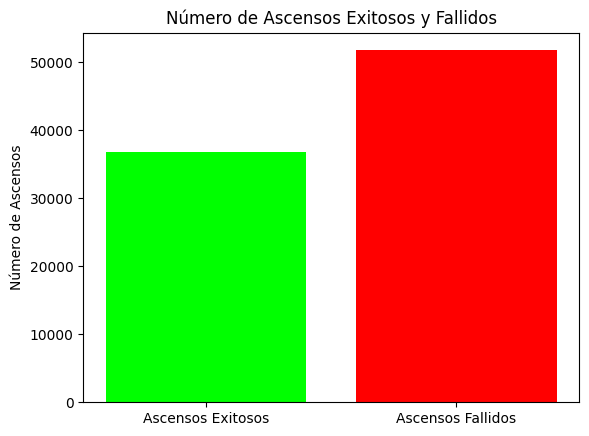

In [25]:
#Grafico de barras del número de ascensos exitosos y fallidos:
labels = ["Ascensos Exitosos", "Ascensos Fallidos"]
values = [ascensos_exitosos, ascensos_fallidos]
plt.bar(labels, values, color=["lime", "red"])
plt.title("Número de Ascensos Exitosos y Fallidos")
plt.ylabel("Número de Ascensos")
plt.show()

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

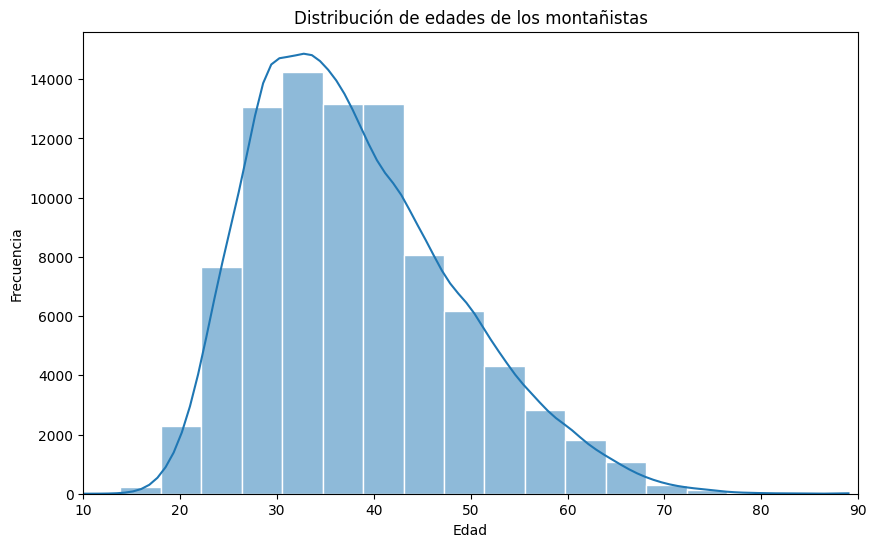

In [26]:
#Distribción de las edades de los montañistas:
plt.figure(figsize = (10,6))
sns.histplot(data = clean_df, x = "age", bins = 40, kde = True, edgecolor = "white")
plt.title("Distribución de edades de los montañistas")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.xlim(10, 90)
plt.show()

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

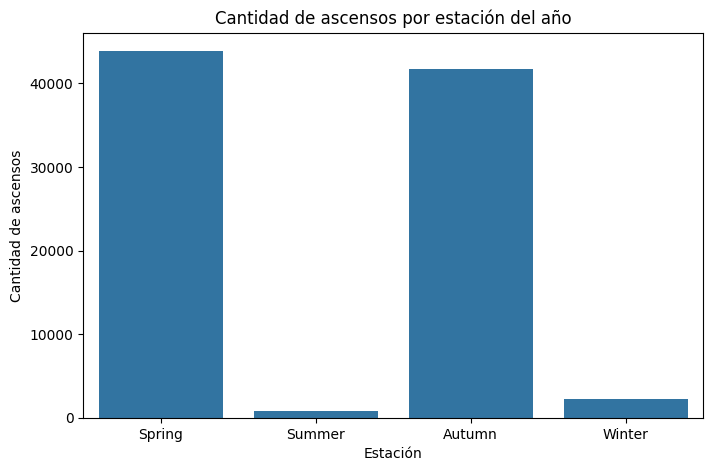

In [27]:
#1. Veamos cómo se distribuye la cantidad total de ascensos por estación del año.
plt.figure(figsize = (8,5))
sns.countplot(data= clean_df, x = "season", order = ["Spring", "Summer", "Autumn", "Winter"])
plt.title("Cantidad de ascensos por estación del año")
plt.xlabel("Estación")
plt.ylabel("Cantidad de ascensos")
plt.show()

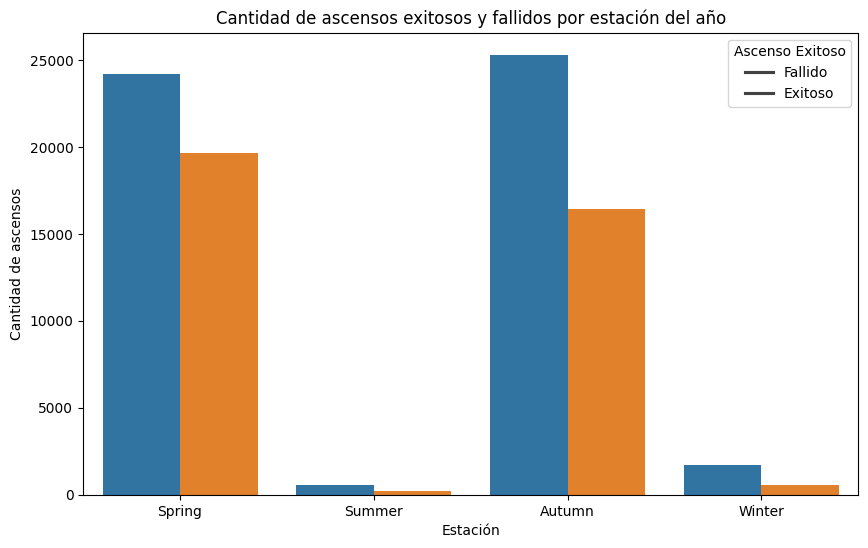

In [28]:
#2. Veamos la cantidad de ascensos exitosos y fallidos por estación del año.
ascensos_estacion = clean_df.groupby(["season", "msuccess"]).size().reset_index(name = "count")
plt.figure(figsize = (10,6))
sns.barplot(data = ascensos_estacion, x = "season", y = "count", hue = "msuccess", order = ["Spring", "Summer", "Autumn", "Winter"])
plt.title("Cantidad de ascensos exitosos y fallidos por estación del año")
plt.xlabel("Estación")
plt.ylabel("Cantidad de ascensos")
plt.legend(title = "Ascenso Exitoso", labels=["Fallido", "Exitoso"])
plt.show()

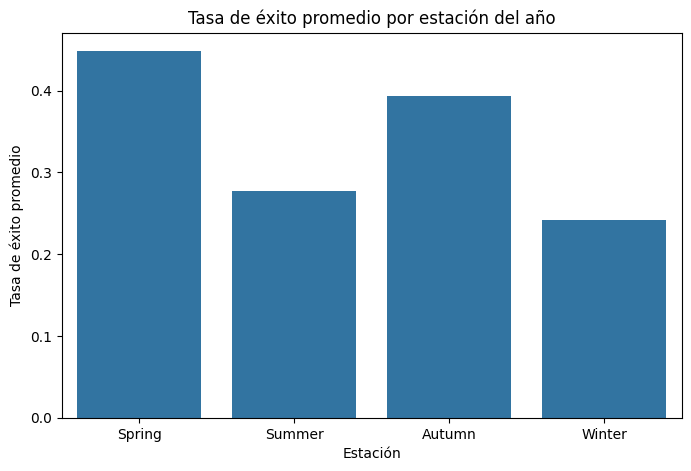

In [29]:
#3. Veamos cuál es la tasa de éxito promedio por estación del año.
tasa_exito_estacion = clean_df.groupby("season")["msuccess"].mean().reset_index()
plt.figure(figsize = (8,5))
sns.barplot(data = tasa_exito_estacion, x = "season", y = "msuccess", order = ["Spring", "Summer", "Autumn", "Winter"])
plt.title("Tasa de éxito promedio por estación del año")
plt.xlabel("Estación")
plt.ylabel("Tasa de éxito promedio")
plt.show()

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

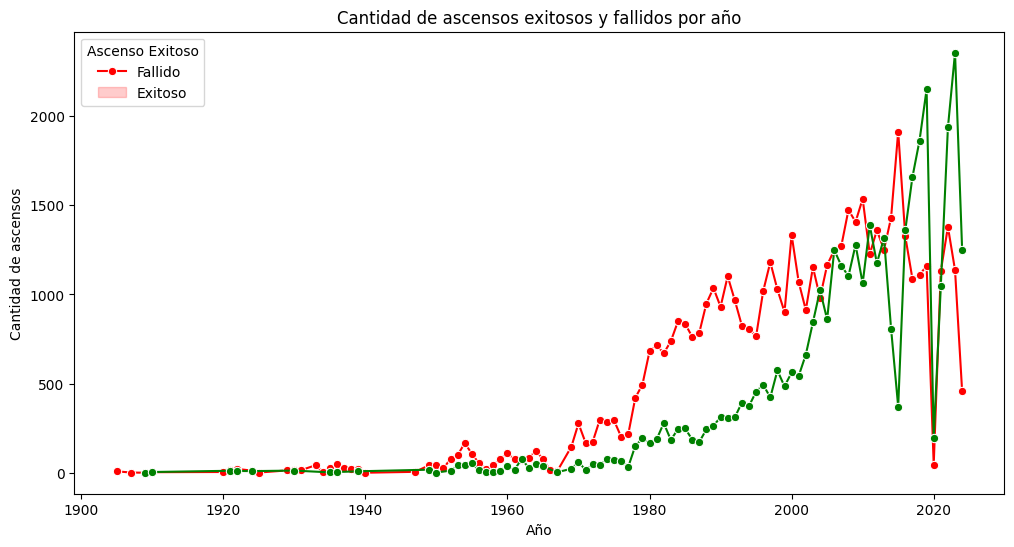

In [30]:
#1. Agrupamos las expediciones por año y éxito, y contamos la cantidad de ascensos en cada grupo.
ascensos_año = clean_df.groupby(["year", "msuccess"]).size().reset_index(name = "count")

#2. Graficamos la cantidad de ascensos exitosos y fallidos por año.
plt.figure(figsize = (12, 6))
sns.lineplot(data = ascensos_año, x = "year", y = "count", hue = "msuccess", marker = "o", palette = {True: "green", False: "red"})
plt.title("Cantidad de ascensos exitosos y fallidos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de ascensos")
plt.legend(title = "Ascenso Exitoso", labels = ["Fallido", "Exitoso"])
plt.show()

Se observa un aumento sostenido en el número de ascensos a lo largo del tiempo, acompañado de un incremento en los ascensos exitosos y una disminución progresiva en los fallidos. Esto podría deberse a los avances tecnológicos y logísticos que han hecho de la escalada una actividad más segura y accesible. Asimismo, destaca la notoria caída en el número de ascensos durante el año 2020, producto de las restricciones impuestas por la pandemia de COVID-19.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

In [31]:
#1. Agrupamos las expediciones por cumbre y contamos la cantidad de ascensos en cada grupo.
ascensos_por_cumbre = clean_df.groupby("pkname").size().reset_index(name = "total_ascensos")

#2. Filtramos las cumbres con al menos 10 ascensos.
cumbres_filtradas = ascensos_por_cumbre[ascensos_por_cumbre["total_ascensos"] >= 10]["pkname"]

#3. Creamos un DataFrame con las cumbres filtradas.
df_cumbres_filtradas = clean_df[clean_df["pkname"].isin(cumbres_filtradas)]

df_cumbres_filtradas.head()

,membid,full_name,sex,yob,age,citizen,expid,peakid,pkname,heightm,year,season,msuccess,success_exp,failed_exp,peak_success_p
0,2,Rohan Buckley,M,1972,29,Australia,AMAD01101,AMAD,Ama Dablam,6814,2001,Spring,False,1123,453,0.712563
1,1,Marc Cameron Fairhead,M,1968,33,Australia,AMAD01101,AMAD,Ama Dablam,6814,2001,Spring,False,1123,453,0.712563
2,3,Mark Schroeder,M,1960,41,Australia,AMAD01101,AMAD,Ama Dablam,6814,2001,Spring,False,1123,453,0.712563
3,4,Colin Smith,M,1966,35,Australia,AMAD01101,AMAD,Ama Dablam,6814,2001,Spring,False,1123,453,0.712563
4,5,Naomi Smith,F,1970,31,Australia,AMAD01101,AMAD,Ama Dablam,6814,2001,Spring,False,1123,453,0.712563


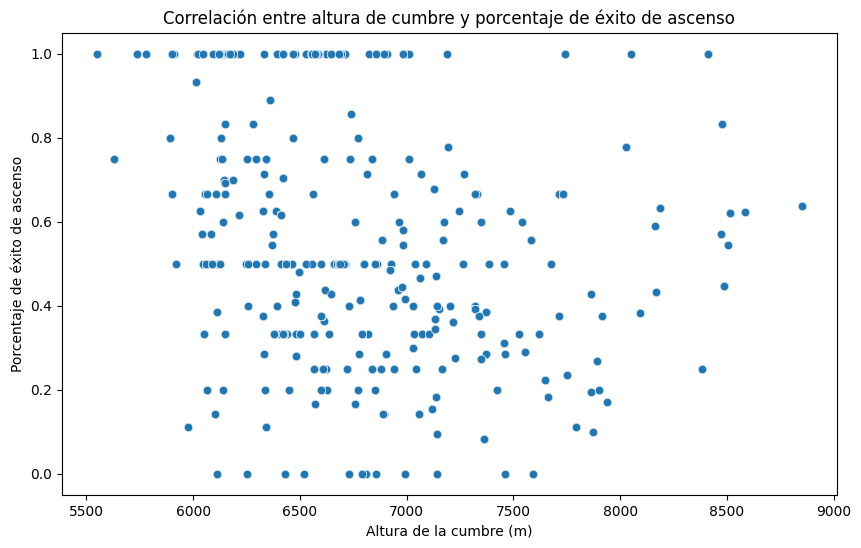

In [32]:
#4. Graficamos el Scatterplot.
plt.figure(figsize = (10,6))
sns.scatterplot(data = df_cumbres_filtradas, x = "heightm", y = "peak_success_p", alpha = 0.6)
plt.title("Correlación entre altura de cumbre y porcentaje de éxito de ascenso")
plt.xlabel("Altura de la cumbre (m)")
plt.ylabel("Porcentaje de éxito de ascenso")
plt.show()

Dada la dispersión de los puntos, no es evidente la existencia de una correlación entre la altura de una cumbre y su porcentaje de éxito. Se puede ver que hay cumbres de menor altura con menor tasa de éxito que otras cumbres más altas, por lo que no se puede concluír que la altura de una cumbre sea un factor tan determinante a la hora de predecir el éxito de su ascenso.

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



#### 5.1 Codificación y normalización:

#### 5.1.1 Codificación de columnas categóricas:

In [33]:
#1. Definimos nuestra matriz de atributos (X) y nuestra etiqueta a predecir (y).
X = clean_df[["age", "sex", "citizen", "season", "heightm", "year", "success_exp", "failed_exp"]]
y = clean_df["msuccess"]

#2. Codificamos las columnas categóricas.
X = pd.get_dummies(X, columns = ["sex", "citizen", "season"], drop_first = True)

X.sample(10)

,age,heightm,year,success_exp,failed_exp,sex_M,sex_X,citizen_Afghanistan/USA,citizen_Albania,citizen_Algeria,...,citizen_Uruguay,citizen_Uzbekistan,citizen_Venezuela,citizen_Vietnam,citizen_W Germany,citizen_W Germany/Iran,citizen_Yugoslavia,season_Spring,season_Summer,season_Winter
73515,41,8516,1997,318,194,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
72755,31,7227,1978,14,37,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2986,39,6814,2003,1123,453,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
20909,34,8188,2011,861,498,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
34923,22,6814,2016,1123,453,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
31235,42,8188,2014,861,498,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
69231,29,8849,1996,1495,852,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
44708,58,6814,2019,1123,453,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18525,39,8188,2009,861,498,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30161,34,8586,2014,127,77,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### 5.1.2 División de datos:

In [34]:
#1. Dividimos los datos en conjuntos de entrenamiento y prueba.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0, stratify = y)

#### 5.1.3 Normalización de atributos:
Como método de normalización, decidimos optar por la estandarización debido principalmente a la diferencia de escalas entre los atributos de nuestra matriz y el impacto que esta podría tener en el entrenamiento de los modelos de clasificación KNN y de regresión logísitica. Por ejemplo, KNN funciona estimando la distancia entre puntos, por lo que de no haber estandarización, la columna "heightm" (con valores en miles) dominaria completamente el cálculo, haciendo que la columna "age" (con valores mucho más pequeños) sea prácticamente irrelevante.

In [35]:
#1. Normalizamos los datos numéricos.
from sklearn.preprocessing import StandardScaler
escala = StandardScaler()

columnas_a_normalizar = ["age", "heightm", "year", "success_exp", "failed_exp"]

X_train[columnas_a_normalizar] = escala.fit_transform(X_train[columnas_a_normalizar])
X_test[columnas_a_normalizar] = escala.transform(X_test[columnas_a_normalizar])

#### 5.2 Creación y entrenamiento de modelos:

#### 5.2.1 Clasificador KNN:
Optamos por n_nightbors = 5 como hiperparámetro, eligiendo un número impar con tal de facilitar la decisión del clasificador.

In [36]:
#1. Definimos un clasificador KNN con k = 5.
from sklearn.neighbors import KNeighborsClassifier
clasificador_knn = KNeighborsClassifier(n_neighbors = 5)

#2. Entrenamos el clasificador con los datos de entrenamiento.
clasificador_knn.fit(X_train, y_train)

#3. Realizamos predicciones sobre el conjunto de prueba.
y_pred_knn = clasificador_knn.predict(X_test)

#### 5.2.2 Árbol de decisión:
Optamos por random_state = 10 como hiperparámetro, esto con la finalidad de asegurar la reproducibilidad del modelo. De este modo, el árbol siempre toma la misma decisión aleatoria en caso de empate, permitiendo que los resultados (como el accuracy) sean consistentes en cada ejecución.

In [37]:
#1. Definimos un arbol de decisión.
from sklearn.tree import DecisionTreeClassifier
clasificador_arbol = DecisionTreeClassifier(random_state = 10)

#2. Entrenamos el clasificador con los datos de entrenamiento.
clasificador_arbol.fit(X_train, y_train)

#3. Realizamos predicciones sobre el conjunto de prueba.
y_pred_arbol = clasificador_arbol.predict(X_test)

#### 5.2.3 Clasificador de Regresión Logística:
Optamos por max_iter = 1000 y random_state = 10 como hiperparámetros, esto con la finalidad de asignar al modelo un mayor número de intentos hasta determinar una solución estable y, al igual que en el caso anterior, asegurar su reproducibilidad respectivamente.

In [38]:
#1. Definimos un clasificador de regresión logística.
from sklearn.linear_model import LogisticRegression
clasificador_logistica = LogisticRegression(max_iter = 1000, random_state = 10)

#2. Entrenamos el clasificador con los datos de entrenamiento.
clasificador_logistica.fit(X_train, y_train)

#3. Realizamos predicciones sobre el conjunto de prueba.
y_pred_logistica = clasificador_logistica.predict(X_test)

#### 5.2.4 Evaluación de éxito:

In [39]:
#1. Importamos las métricas necesarias para evaluar los modelos.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### 5.2.4.1 Clasificador KNN:

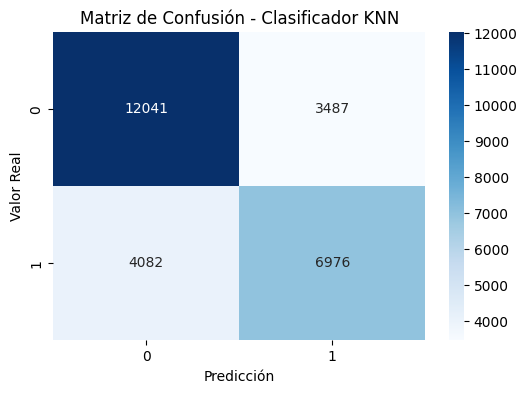

In [40]:
#1. Evaluamos el desempeño del clasificador KNN.
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
confusion_knn = confusion_matrix(y_test, y_pred_knn)

#2. Graficamos la matriz de confusión del clasificador KNN.
plt.figure(figsize = (6,4))
sns.heatmap(confusion_knn, annot = True, fmt = "d", cmap = "Blues")
plt.title("Matriz de Confusión - Clasificador KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

#### 5.2.4.2 Clasificador de Árbol de Decisión:

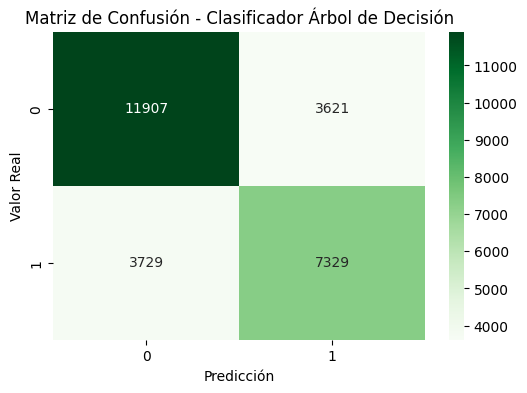

In [41]:
#1. Evaluamos el desempeño del clasificador de árbol de decisión.
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol)
recall_arbol = recall_score(y_test, y_pred_arbol)
confusion_arbol = confusion_matrix(y_test, y_pred_arbol)

#2. Graficamos la matriz de confusión del clasificador de árbol de decisión.
plt.figure(figsize = (6,4))
sns.heatmap(confusion_arbol, annot = True, fmt = "d", cmap = "Greens")
plt.title("Matriz de Confusión - Clasificador Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

#### 5.2.4.3 Clasificador de Regresión Logística:

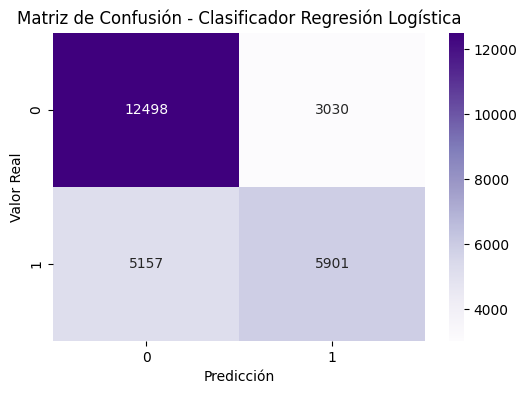

In [42]:
#1. Evaluamos el desempeño del clasificador de regresión logística.
accuracy_logistica = accuracy_score(y_test, y_pred_logistica)
precision_logistica = precision_score(y_test, y_pred_logistica)
recall_logistica = recall_score(y_test, y_pred_logistica)
confusion_logistica = confusion_matrix(y_test, y_pred_logistica)

#2. Graficamos la matriz de confusión del clasificador de regresión logística.
plt.figure(figsize = (6,4))
sns.heatmap(confusion_logistica, annot = True, fmt = "d", cmap = "Purples")
plt.title("Matriz de Confusión - Clasificador Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

Con la finalidad de facilitar la interpretación de los resultados, pasaremos estas evaluaciones a un nuevo DataFrame:

In [43]:
# 1. Creamos un diccionario con los resultados.
resultados = {
    "Modelo": ["Clasificador KNN", "Árbol de Decisión", "Regresión Logística"],
    "Accuracy": [accuracy_knn, accuracy_arbol, accuracy_logistica],
    "Precision": [precision_knn, precision_arbol, precision_logistica],
    "Recall": [recall_knn, recall_arbol, recall_logistica]
}

# 2. Convertimos el diccionario en un DataFrame.
df_resultados = pd.DataFrame(resultados)

df_resultados.head()

,Modelo,Accuracy,Precision,Recall
0,Clasificador KNN,0.715301,0.666730,0.630855
1,Árbol de Decisión,0.723539,0.669315,0.662778
2,Regresión Logística,0.692056,0.660732,0.533641


#### 5.3 Análisis de resultados:

* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 

A partir de los resultados obtenidos se puede notar que los tres métodos de clasificación tienen un porcentaje de exactitud de aproximadamente un 70%, siendo el árbol de decisión el más exacto con un 72,35%. En cuanto a la precisión de los tres métodos, se obtiene un porcentaje de aproximadamente un 66%, mientras que en el caso de la sensibilidad, la diferencia es más evidente, siendo el árbol de decisión el método con mayor sensibilidad, generando así menos falsos negativos.

* ¿Fue posible construir un predictor efectivo? Justique.

Sí, fue posible construir un predictor efectivo, particularmente el árbol de decisión. Dicho clasificador obtuvo aproximadamente un 72,3% de exactitud, lo que demuestra que atributos como la edad de los montañistas, la altura del monte o la temporada del año son determinantes al momento de definir el éxito de una expedición. Además, su matriz de confusión evidencia que este método es el más efectivo para predecir verdaderos positivos.